# Part 1

In [2]:
import duckdb
import os

# Create a non-persistent connection (the database exists only while the connection is alive and disappears when it is closed)
con = duckdb.connect(database=":memory:")

# You need to create a secret table with all the S3 credentials
con.execute(
    f"""
    CREATE SECRET secret_s3 (
    TYPE S3,
    KEY_ID '{os.environ["AWS_ACCESS_KEY_ID"]}',
    SECRET '{os.environ["AWS_SECRET_ACCESS_KEY"]}',
    ENDPOINT '{os.environ["AWS_S3_ENDPOINT"]}',
    SESSION_TOKEN '{os.environ["AWS_SESSION_TOKEN"]}',
    REGION 'eu-west-1',
    URL_STYLE 'path',
    SCOPE 's3://projet-funathon/'
    );
    """
)

RANDOM_STATE = 202605

In [3]:
#| code-fold: true
#| code-overflow: scroll
import pandas as pd

# We load all transactions made in France between 2010 and 2022
trans = pd.read_parquet('https://minio.lab.sspcloud.fr/projet-funathon/2026/project1/data/1_input/transactions_EN.parquet')

In [4]:
trans.shape

(9999635, 43)

In [5]:
trans.dtypes

trans_date            object
trans_year             int64
trans_month            int64
price                float64
prop_type              int32
prop_year_harm         int32
prop_loc_dep          object
prop_loc_citycode     object
prop_loc_x           float64
prop_loc_y           float64
dist_tosea           float64
n_floors               int32
n_bath                 int32
n_show                 int32
n_sink                 int32
n_wc                   int32
n_mrooms               int32
n_eatr                 int32
n_slr                  int32
n_kit8                 int32
n_kit9                 int32
n_washr                int32
n_ancrooms             int32
n_rooms                int32
farea                  int32
has_water              int32
has_elec               int32
stair                  int32
has_gas                int32
has_elevator           int32
has_cheating           int32
has_rchute             int32
has_mdrainage          int32
nth_floor              int32
s_land_artif  

In [6]:
trans.columns

Index(['trans_date', 'trans_year', 'trans_month', 'price', 'prop_type',
       'prop_year_harm', 'prop_loc_dep', 'prop_loc_citycode', 'prop_loc_x',
       'prop_loc_y', 'dist_tosea', 'n_floors', 'n_bath', 'n_show', 'n_sink',
       'n_wc', 'n_mrooms', 'n_eatr', 'n_slr', 'n_kit8', 'n_kit9', 'n_washr',
       'n_ancrooms', 'n_rooms', 'farea', 'has_water', 'has_elec', 'stair',
       'has_gas', 'has_elevator', 'has_cheating', 'has_rchute',
       'has_mdrainage', 'nth_floor', 's_land_artif', 's_land_agri',
       's_land_nat', 'n_garage', 'n_pool', 'n_terrace', 'n_attic', 'n_basmt',
       'n_otherannex'],
      dtype='object')

In [7]:
trans.index

RangeIndex(start=0, stop=9999635, step=1)

In [8]:
trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999635 entries, 0 to 9999634
Data columns (total 43 columns):
 #   Column             Dtype  
---  ------             -----  
 0   trans_date         object 
 1   trans_year         int64  
 2   trans_month        int64  
 3   price              float64
 4   prop_type          int32  
 5   prop_year_harm     int32  
 6   prop_loc_dep       object 
 7   prop_loc_citycode  object 
 8   prop_loc_x         float64
 9   prop_loc_y         float64
 10  dist_tosea         float64
 11  n_floors           int32  
 12  n_bath             int32  
 13  n_show             int32  
 14  n_sink             int32  
 15  n_wc               int32  
 16  n_mrooms           int32  
 17  n_eatr             int32  
 18  n_slr              int32  
 19  n_kit8             int32  
 20  n_kit9             int32  
 21  n_washr            int32  
 22  n_ancrooms         int32  
 23  n_rooms            int32  
 24  farea              int32  
 25  has_water         

In [9]:
trans.describe()

,trans_year,trans_month,price,prop_type,prop_year_harm,prop_loc_x,prop_loc_y,dist_tosea,n_floors,n_bath,...,nth_floor,s_land_artif,s_land_agri,s_land_nat,n_garage,n_pool,n_terrace,n_attic,n_basmt,n_otherannex
count,9.999635e+06,9.999635e+06,9.999635e+06,9.999635e+06,9.999635e+06,9.986618e+06,9.986618e+06,9.986618e+06,9.999635e+06,9.999635e+06,...,9.999635e+06,9.999635e+06,9.999635e+06,9.999635e+06,9.999635e+06,9.999635e+06,9.999635e+06,9.999635e+06,9.999635e+06,9.999635e+06
mean,2.017001e+03,6.522953e+00,2.402853e+05,1.400009e+00,1.947800e+03,2.359369e+00,4.648919e+01,8.124287e+03,2.360037e+00,6.714670e-01,...,1.033532e+00,5.055850e+02,6.610428e+02,8.130392e+01,6.733883e-01,3.964305e-02,2.284278e-01,3.575668e-01,4.887532e-01,4.949211e-02
std,4.320021e+00,3.447693e+00,2.231492e+05,4.898999e-01,6.709590e+01,5.261263e+00,4.797850e+00,3.517539e+03,2.448644e+00,5.181332e-01,...,3.936771e+00,1.302745e+03,1.109009e+04,3.772332e+03,5.966201e-01,1.951191e-01,4.394879e-01,5.194642e-01,6.196501e-01,2.450435e-01
min,2.010000e+03,1.000000e+00,2.566987e+03,1.000000e+00,1.200000e+03,-6.314683e+01,-2.138736e+01,2.455657e-04,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.013000e+03,4.000000e+00,1.171319e+05,1.000000e+00,1.918000e+03,5.278337e-01,4.474772e+01,1.000000e+04,1.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.017000e+03,7.000000e+00,1.858936e+05,1.000000e+00,1.971000e+03,2.381033e+00,4.722144e+01,1.000000e+04,2.000000e+00,1.000000e+00,...,0.000000e+00,1.810000e+02,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.021000e+03,1.000000e+01,2.918414e+05,2.000000e+00,1.995000e+03,4.545148e+00,4.883395e+01,1.000000e+04,3.000000e+00,1.000000e+00,...,1.000000e+00,6.780000e+02,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
max,2.024000e+03,1.200000e+01,1.938854e+07,2.000000e+00,2.025000e+03,5.582849e+01,5.108214e+01,1.000000e+04,9.900000e+01,3.000000e+00,...,9.900000e+01,1.684404e+06,2.210927e+06,2.877477e+06,3.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,3.000000e+00


In [10]:
trans.head()

,trans_date,trans_year,trans_month,price,prop_type,prop_year_harm,prop_loc_dep,prop_loc_citycode,prop_loc_x,prop_loc_y,...,nth_floor,s_land_artif,s_land_agri,s_land_nat,n_garage,n_pool,n_terrace,n_attic,n_basmt,n_otherannex
0,2017-04-25,2017,4,144066.438486,1,2014,60,60370,2.106281,49.258202,...,0,802,0,0,1,0,0,0,0,0
1,2012-08-12,2012,8,158839.793280,1,1987,60,60003,2.173426,49.520604,...,0,859,0,0,1,0,0,0,0,0
2,2012-09-13,2012,9,70960.301727,1,2006,60,60592,1.735172,49.415124,...,0,765,0,0,1,0,0,0,0,0
3,2013-02-26,2013,2,43676.516263,1,1992,60,60057,2.083790,49.420146,...,0,769,0,0,1,0,0,0,0,0
4,2017-03-05,2017,3,194822.649580,1,1971,60,60513,2.382319,49.208644,...,0,880,0,0,1,0,0,0,0,0


In [11]:
trans = trans[trans["prop_loc_dep"].isin(["75", "77", "78", "91", "92", "93", "94", "95"])]

In [12]:
trans["price_sqm"] = trans["price"] / trans["farea"]

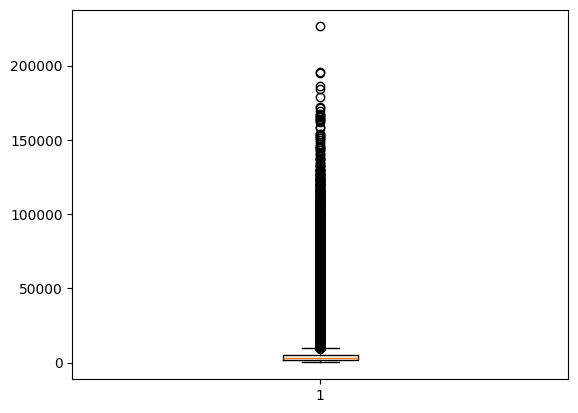

In [13]:
import matplotlib.pyplot as plt

plt.boxplot(trans["price_sqm"])
plt.show()

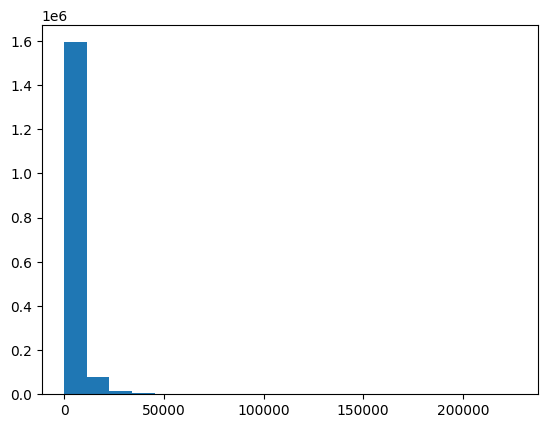

In [14]:
plt.hist(trans["price_sqm"], bins=20)
plt.show()

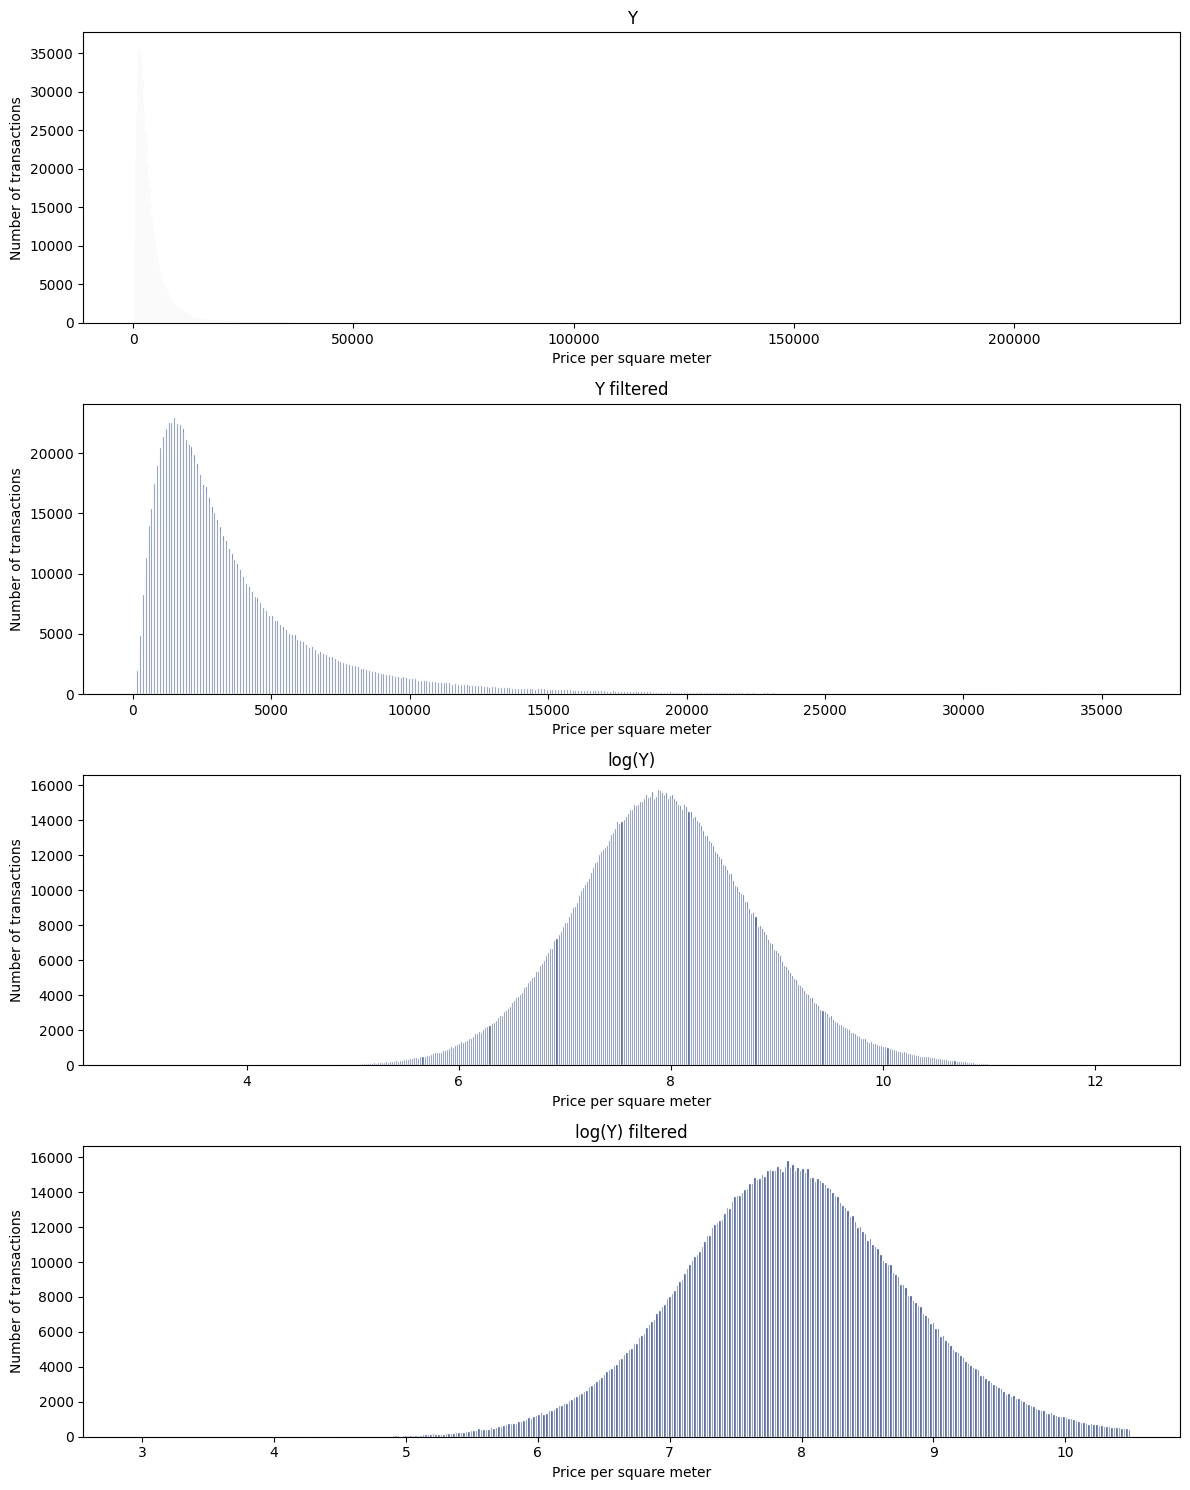

In [15]:
import numpy as np
import matplotlib.pyplot as plt

y = trans["price_sqm"]
p = np.percentile(y, 99.5)

fig, axes = plt.subplots(4, 1, figsize=(12, 15))

for ax, (data, label) in zip(axes, [(y, "Y"), (y[y <= p], "Y filtered"), (np.log(y), "log(Y)"), (np.log(y[y <= p]), "log(Y) filtered")]):
    ax.hist(data, bins="auto", edgecolor="white", color="#334887", alpha=0.95)
    ax.set_title(label)
    ax.set_xlabel("Price per square meter")
    ax.set_ylabel("Number of transactions")

plt.tight_layout()
plt.show()

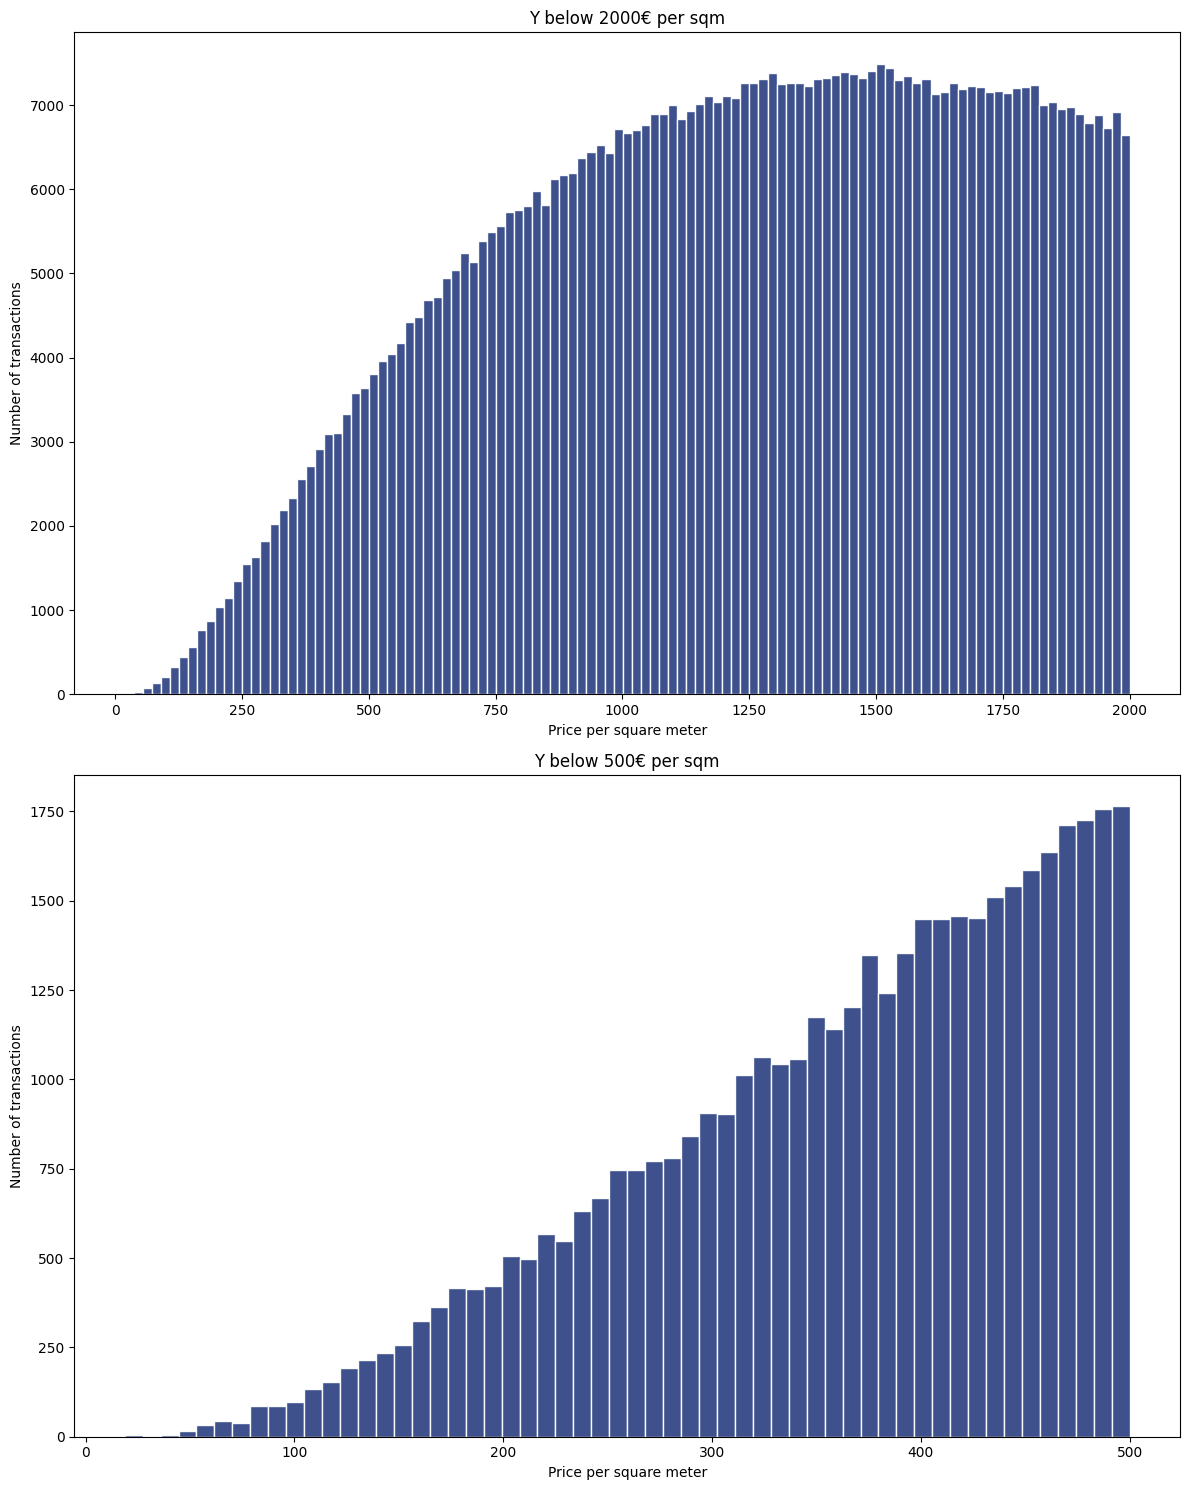

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 15))

for ax, (data, label) in zip(axes, [(y[y <= 2000], "Y below 2000€ per sqm"), (y[y <= 500], "Y below 500€ per sqm")]):
    ax.hist(data, bins="auto", edgecolor="white", color="#334887", alpha=0.95)
    ax.set_title(label)
    ax.set_xlabel("Price per square meter")
    ax.set_ylabel("Number of transactions")

plt.tight_layout()
plt.show()

In [17]:
n0 = trans.shape[0]
print(f"{n0} rows before filtering")

# Apply some deterministic threshold on the dataframe
trans = trans[(trans["price_sqm"] < 200000) & (trans["price_sqm"] > 100)]

print(f"{trans.shape[0]} rows after deterministic filtering")

# Apply IQR methods for the outlier removal
def outlier_transform(y, lower=0.1, upper=0.9):
    """
    Transform Y target to log(Y) and remove outliers with IQR method

    Args :
        y : target
        lower: lower quantile for the IQR
        upper: upper quantile for the IQR
    """
    Q_lower = np.quantile(y, lower)
    Q_upper = np.quantile(y, upper)
    IQR = Q_upper - Q_lower

    mask = (y >= Q_lower - 1.5 * IQR) & (y <= Q_upper + 1.5 * IQR)
    return mask

mask = outlier_transform(trans["price_sqm"])
trans = trans[mask].reset_index(drop=True)

n1 = trans.shape[0]

print(f"{n1} rows after deterministic and statistic filtering")

1696331 rows before filtering
1695973 rows after deterministic filtering
1663499 rows after deterministic and statistic filtering


In [18]:
trans = trans.dropna(subset = "price_sqm")

In [19]:
trans.columns

Index(['trans_date', 'trans_year', 'trans_month', 'price', 'prop_type',
       'prop_year_harm', 'prop_loc_dep', 'prop_loc_citycode', 'prop_loc_x',
       'prop_loc_y', 'dist_tosea', 'n_floors', 'n_bath', 'n_show', 'n_sink',
       'n_wc', 'n_mrooms', 'n_eatr', 'n_slr', 'n_kit8', 'n_kit9', 'n_washr',
       'n_ancrooms', 'n_rooms', 'farea', 'has_water', 'has_elec', 'stair',
       'has_gas', 'has_elevator', 'has_cheating', 'has_rchute',
       'has_mdrainage', 'nth_floor', 's_land_artif', 's_land_agri',
       's_land_nat', 'n_garage', 'n_pool', 'n_terrace', 'n_attic', 'n_basmt',
       'n_otherannex', 'price_sqm'],
      dtype='object')

In [20]:
trans.head()

,trans_date,trans_year,trans_month,price,prop_type,prop_year_harm,prop_loc_dep,prop_loc_citycode,prop_loc_x,prop_loc_y,...,s_land_artif,s_land_agri,s_land_nat,n_garage,n_pool,n_terrace,n_attic,n_basmt,n_otherannex,price_sqm
0,2024-05-03,2024,5,101258.225109,1,1900,93,93048,2.455521,48.870076,...,133,0,0,1,0,1,1,1,1,778.909424
1,2016-09-10,2016,9,108551.691624,1,1979,77,77495,2.629716,48.585046,...,1258,0,0,1,1,0,0,1,2,868.413533
2,2023-09-02,2023,9,103358.330665,1,1900,77,77114,2.658776,48.725826,...,1271,0,0,2,1,0,1,2,0,847.199432
3,2011-08-18,2011,8,631713.329846,1,1977,77,77089,2.944329,48.508707,...,1146,0,0,1,1,2,0,1,0,4974.120707
4,2015-03-02,2015,3,174613.395677,1,1971,77,77269,2.702652,48.548586,...,1373,440,0,1,1,1,1,1,0,1322.828755


In [21]:
df = trans.drop(columns=["price", "prop_loc_dep", "prop_loc_citycode", "dist_tosea"])

In [22]:
# Printing all rows containing at least one NA
print(df[df.isna().any(axis=1)])

# Filtering NA values
df = df.dropna()

        trans_date  trans_year  trans_month  prop_type  prop_year_harm  \
33568   2015-02-07        2015            2          1            2015   
33569   2015-04-30        2015            4          1            1957   
33570   2017-03-31        2017            3          1            1960   
33571   2011-07-22        2011            7          1            1921   
33572   2022-07-22        2022            7          1            1960   
...            ...         ...          ...        ...             ...   
540890  2016-01-13        2016            1          1            1925   
540891  2014-08-21        2014            8          1            1934   
540892  2023-03-20        2023            3          1            1906   
540893  2013-07-27        2013            7          1            1929   
540894  2024-11-16        2024           11          1            1978   

        prop_loc_x  prop_loc_y  n_floors  n_bath  n_show  ...  s_land_artif  \
33568          NaN         NaN  

In [23]:
df["prop_type"] = pd.Categorical(
    df["prop_type"].astype(str),
    categories=["1", "2"],
    ordered=False
).rename_categories({"1": "House", "2": "Flat"})

In [24]:
counts = df.value_counts("prop_year_harm").reset_index()
counts[counts["prop_year_harm"] < 1850].describe() # there more than 500 different years of construction, going from 13th century to now. Maybe we can bundle together years before 1850 and group them by decade

counts_10 = ((df["prop_year_harm"] // 10)*10).value_counts().reset_index()  # 82 modalities
counts_10[counts_10["prop_year_harm"] < 1850].describe()  # years before 1850 represent 64 modalities with maximal class of about two thousands operations - ok
counts_10[counts_10["prop_year_harm"] < 1850]["count"].sum()

# Replacing year of construction by decade and merging together all years before 1850
df['prop_year_harm_10'] = (df['prop_year_harm'] // 10)*10
df['prop_year_harm_10'] = df['prop_year_harm_10'].where(df['prop_year_harm_10'] >= 1850, 1840)

# Dropping old column
df = df.drop(columns=["prop_year_harm"])

In [25]:
from sklearn.model_selection import train_test_split

# Split features / target
X = df.drop(columns=["price_sqm"])  # X must contain only the features we'll learn from
y = df["price_sqm"]  # target must be a dataframe with 1 column

# Split train / test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import FunctionTransformer


def date_to_days(X: pd.Series, ref_date:pd.Timestamp):
    # converts a date to a difference to ref_date :
    diff_dt = pd.to_datetime(X) - ref_date
    # Extract days part from datetime object
    diff_dt = diff_dt.dt.days
    # Transform it from a Pandas series to a Numpy nd array, used by scikit learn for input
    diff_dt = diff_dt.to_numpy().reshape(-1, 1)

    return diff_dt

date_transformer = FunctionTransformer(
    date_to_days,
    kw_args={"ref_date": pd.Timestamp('2010-01-01 00:00')}
    )

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["prop_type", "prop_year_harm_10"]),  # one-hot encoder on feature
        ("dat", date_transformer, "trans_date") # feature time since 01-01-2010
    ],
    remainder="passthrough"  # to keep features not transformed
)

In [27]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

def log_transform(y):
    return np.log10(y)

def inverse_log_transform(y):
    return 10 ** y

y_transformer = FunctionTransformer(
    func=log_transform,
    inverse_func=inverse_log_transform)

# Other option with Numpy :
# y_transformer = FunctionTransformer(
#     func=np.log,
#     inverse_func=np.exp)

rf_params = {
    "n_estimators": 100,
    "max_depth": 5,
    "max_features": "sqrt",
    "min_samples_split": 2,
    "min_samples_leaf": 10,
    "random_state": RANDOM_STATE,
    "oob_score": True,
    "n_jobs": -1,  # The number of jobs to run in parallel, -1 using all processors
}

rf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('RF', RandomForestRegressor(**rf_params))
])

model = TransformedTargetRegressor(
    regressor=rf_pipeline,
    transformer=y_transformer
)

In [28]:
rf_pipeline   # access to the first step

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('RF', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('dat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

# Part 2a

In [181]:
rf = RandomForestRegressor(
    n_estimators=50,
    max_features="sqrt",
    min_samples_leaf=10,
    random_state=RANDOM_STATE,
    oob_score=True
)

In [33]:
X_train = X_train.drop(columns=["trans_date", "prop_type"])
X_test = X_test.drop(columns=["trans_date", "prop_type"])

In [183]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

In [184]:
rf.oob_score_

0.29745347980894044

In [185]:
from sklearn.metrics import mean_squared_error

mean_squared_error(rf.predict(X_test), y_test)

7521440.496395447

In [186]:
# Sample the train dataset using Pandas' index
y_train_df = pd.DataFrame(y_train)
y_train_df["quantile"] = pd.qcut(y_train_df["price_sqm"], q=100, labels=False) ## allows to discretly cut along quantiles
y_sub = y_train_df.groupby("quantile").sample(frac=0.1, random_state= RANDOM_STATE)  # sampling by quantile 

y_sub = y_sub["price_sqm"] # converting to pandas.series
X_sub = X_train.filter(items=y_sub.index, axis=0 )  # sampling X_train

In [187]:
rf_params = {
    "n_estimators": 50,
    "max_features": "sqrt",
    "min_samples_leaf": 10,
    "random_state": RANDOM_STATE,
    "oob_score": True
}

In [188]:
import warnings

metric = "r2"
min_estimators=5
max_estimators=150

rf = RandomForestRegressor(
    warm_start=True,
    **rf_params,
)

oob_scores = []
warnings.filterwarnings("ignore", message="Some inputs do not have OOB scores")
# filterwarnings remove some warnings messages
for n in range(min_estimators, max_estimators, 20):
    rf.set_params(n_estimators=n)
    rf.fit(X_sub, y_sub)
    if metric == "r2":
        oob_scores.append((n, 1 - rf.oob_score_))
    elif metric == "neg_root_mean_squared_error":
        mse = np.mean((y_sub - rf.oob_prediction_) ** 2)
        oob_scores.append((n, np.sqrt(mse)))
    else:
        mae = np.mean(np.abs(y_sub - rf.oob_prediction_))
        oob_scores.append((n, mae))
warnings.resetwarnings()

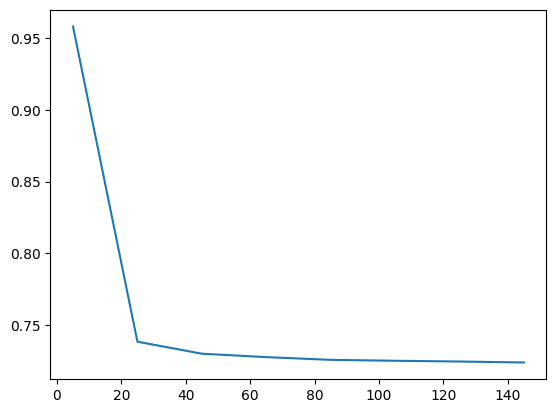

In [189]:
oob_scores = np.array(oob_scores)

plt.plot(oob_scores[:,0], oob_scores[:,1])

In [34]:
import matplotlib.pyplot as plt
import warnings

rf_params = {
    "max_depth": 8,
    "max_features": "sqrt",
    "min_samples_split": 5,
    "min_samples_leaf": 10,
    "random_state": RANDOM_STATE,
}

def rf_error_oob_plot(X_train,
                      y_train,
                      subsample=0.1,
                      min_estimators=15,
                      max_estimators=150,
                      metric='r2',
                      **rf_params):
    """
    Plot error OOB convergence by the number of trees

    Args:
        X_train: features
        y_train: target
        subsample: rate of sample for X_train
        min_estimators: number min of trees
        max_estimators: number max of trees
        metric : 'r2',  'rmse' or 'mae'
    """

    # --- Stratified sampling of training set ---
    y_train_df = pd.DataFrame(y_train)
    y_train_df["quantile"] = pd.qcut(y_train_df["price_sqm"], q=100, labels=False) ## allows to discretly cut along quantiles
    y_sub = y_train_df.groupby("quantile").sample(frac=0.1, random_state= RANDOM_STATE)  # sampling by quantile 

    y_sub = y_sub["price_sqm"] # converting to pandas.series
    X_sub = X_train.filter(items=y_sub.index, axis=0 )  # sampling X_train

    # --- Training with warm start ---
    rf = RandomForestRegressor(
        oob_score=True,
        warm_start=True,
        **rf_params,
    )

    oob_scores = []
    warnings.filterwarnings("ignore", message="Some inputs do not have OOB scores")
    for n in range(min_estimators, max_estimators, 5):
        rf.set_params(n_estimators=n)
        rf.fit(X_sub, y_sub)
        if metric == "r2":
            oob_scores.append((n, 1 - rf.oob_score_))
        elif metric == "neg_root_mean_squared_error":
            mse = np.mean((y_sub - rf.oob_prediction_) ** 2)
            oob_scores.append((n, np.sqrt(mse)))
        else:
            mae = np.mean(np.abs(y_sub - rf.oob_prediction_))
            oob_scores.append((n, mae))
    warnings.resetwarnings()

    # Generate the "OOB error rate" vs. "n_estimators" plot.
    xs, ys = zip(*oob_scores)

    fig, ax = plt.subplots()
    ax.plot(xs, ys)
    ax.set_xlim(min_estimators, max_estimators)
    ax.set_xlabel("n_trees")
    ax.set_ylabel(f"OOB error ({metric})")
    plt.close(fig)

    return fig

In [35]:
oob_error_ntrees = rf_error_oob_plot(X_train, y_train)

In [36]:
from sklearn.model_selection import train_test_split

# Split features / target
X = df.drop(columns=["price_sqm"])  # X must contain only the features we'll learn from
y = df["price_sqm"]  # target must be a dataframe with 1 column

# Split train / test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [37]:
param_grid = {
    "regressor__RF__n_estimators": [80],
    "regressor__RF__max_features": ["sqrt"],
    "regressor__RF__min_samples_leaf": [40, 50, 75],
    "regressor__RF__max_depth" : [8, 13],
}

In [38]:
from sklearn.model_selection import GridSearchCV

# Grid search
grid_search = GridSearchCV(
    estimator=model, # it is the TransformedTargetRegressor created in the preprocessing part
    param_grid=param_grid,
    cv=4,  # number of folds
    scoring="r2", # 'r2' or 'neg_root_mean_squared_error' or 'neg_mean_absolute_error'
    n_jobs=-1,
    verbose=1
)

# Train
grid_search.fit(X_train, y_train)

Fitting 4 folds for each of 6 candidates, totalling 24 fits


/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/wor

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",TransformedTa...f4784d59a80>))
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__RF__max_depth': [8, 13], 'regressor__RF__max_features': ['sqrt'], 'regressor__RF__min_samples_leaf': [40, 50, ...], 'regressor__RF__n_estimators': [80]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the co

In [39]:
grid_search.best_params_

{'regressor__RF__max_depth': 13,
 'regressor__RF__max_features': 'sqrt',
 'regressor__RF__min_samples_leaf': 40,
 'regressor__RF__n_estimators': 80}

In [40]:
rf_model_final = grid_search.best_estimator_

In [41]:
print(type(rf_model_final))

rf_model_final.fit(X_train, y_train)

<class 'sklearn.compose._target.TransformedTargetRegressor'>


/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/wor

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...ate=202605))])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",FunctionTrans...7f4784d59a80>)
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",None
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",None
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('dat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the tra

In [42]:
y_pred_test = rf_model_final.predict(X_test)

/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/wor

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("RMSE - ", np.sqrt(mean_squared_error(y_test, y_pred_test)))
print("MAE - ", mean_absolute_error(y_test, y_pred_test))
print("R² - ", r2_score(y_test, y_pred_test))


In [ ]:
import matplotlib.pyplot as plt


def predicted_actual_plot(y_test, y_pred_test, model_name):
    fig, ax = plt.subplots(figsize=(7, 7))

    ax.scatter(y_test, y_pred_test, alpha=0.3, s=5, label="Predictions")

    lims = [min(y_test.min(), y_pred_test.min()),
            max(y_test.max(), y_pred_test.max())]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")

    ax.set_xlabel("Actual values (log)")
    ax.set_ylabel("Predicted values (log)")
    ax.set_title(f"Comparison of predicted values vs. actual values on the test set\n({model_name})")
    ax.legend()
    plt.xscale('log')
    plt.yscale('log')
    plt.tight_layout()
    return fig


predicted_actual_plot(y_test, y_pred_test, "Random Forest")

In [ ]:
def build_feature_dict(loc_x, loc_y, fare_a, prop_type, feature_dict=None):
    """Return a feature dict ready for the model.

    If `feature_dict` is provided, it is returned unchanged.
    Otherwise, a default dict is built from the required arguments.
    Args:
        loc_x, loc_y : ()
    """
    if feature_dict is not None:
        return feature_dict

    _prop_type_map = {1: "House", 2: "Flat"}
    prop_type_str = _prop_type_map.get(prop_type, str(prop_type))

    return {
        "farea": fare_a,
        "trans_date": "01/02/2026",
        "trans_year": 2026,
        "trans_month": 2,
        "prop_type": prop_type_str,
        "prop_year_harm_10": 2000,
        "prop_loc_x": loc_x,
        "prop_loc_y": loc_y,
        "has_cheating": 0,
        "has_elec": 2,
        "has_elevator": 2,
        "has_gas": 2,
        "has_mdrainage": 2,
        "has_rchute": 0,
        "has_water": 2,
        "n_floors": 4,
        "n_bath": 1,
        "n_eatr": 1,
        "n_kit8": 1,
        "n_kit9": 0,
        "n_ancrooms": 0,
        "n_attic": 1,
        "n_basmt": 1,
        "n_garage": 2,
        "n_pool": 0,
        "n_mrooms": 7,
        "n_otherannex": 0,
        "n_rooms": 7,
        "n_show": 1,
        "n_sink": 1,
        "n_slr": 2,
        "n_terrace": 1,
        "n_washr": 1,
        "n_wc": 1,
        "nth_floor": 3,
        "s_land_agri": 0,
        "s_land_artif": 0,
        "s_land_nat": 0,
        "stair": 2,
    }

In [ ]:
prediction_examples = {
    "adresse1" : {"nom" : "88 avenue Verdier 92120 Montrouge", "fare_a" : 80, "loc_x": 2.244608, "loc_y": 48.8865792, "prop_type" : 2},
    "adresse2" : {"nom" : "3 rue Sadi Carnot 78120 Rambouillet", "fare_a" : 140, "loc_x": 1.8300153, "loc_y": 48.6431721, "prop_type" : 1},
    "adresse3" : {"nom" : "1 rue des arts 92700 Colombes", "fare_a" : 35, "loc_x": 2.2410483, "loc_y": 48.9109437, "prop_type" : 2},
    "adresse4" : {"nom" : "152 Rue de Sèvres 75015 Paris", "fare_a" : 93, "loc_x": 2.3146301, "loc_y": 48.8462097, "prop_type" : 2},
    "adresse5" : {"nom" : "3 rue Paul Doumer 93100 Montreuil", "fare_a" : 105, "loc_x": 2.45626, "loc_y": 48.861197, "prop_type" : 1},  
}

In [ ]:
import pandas as pd

# Build a DataFrame with one row per address — batching is faster than
# calling predict() in a loop and ensures consistent column ordering.
rows = []
for key, infos in prediction_examples.items():
    features = build_feature_dict(
        loc_x=infos["loc_x"],
        loc_y=infos["loc_y"],
        fare_a=infos["fare_a"],
        prop_type=infos["prop_type"],
    )
    features["adresse"] = infos["nom"]
    features["id"] = key
    rows.append(features)

X_examples = pd.DataFrame(rows)

# Keep metadata aside; the model only sees the feature columns it was trained on.
meta_cols = ["id", "adresse"]
feature_cols = [c for c in X_examples.columns if c not in meta_cols]

# Predicted price per square meter
predicted_price_sqm = rf_model_final.predict(X_examples[feature_cols])

results = X_examples[meta_cols].copy()
results["price_per_sqm"] = predicted_price_sqm.round(0)
results["surface"]       = X_examples["farea"].values
results["total_price"]   = (results["price_per_sqm"] * results["surface"]).round(0)

for _, row in results.iterrows():
    print(
        f"For the property at {row['adresse']} "
        f"({row['surface']:.0f} sqm), the estimated price is "
        f"{row['price_per_sqm']:,.0f} €/sqm, "
        f"i.e. a total of about {row['total_price']:,.0f} €."
    )

# Part2b

In [43]:
from sklearn.ensemble import HistGradientBoostingRegressor

X_train = X_train.drop(columns=["prop_type", "trans_date"])
X_test  =  X_test.drop(columns=["prop_type", "trans_date"])

y_train = pd.read_parquet("https://minio.lab.sspcloud.fr/projet-funathon/2026/project1/data/2_preprocessing/y_train.parquet")["price_sqm"]
y_test  = pd.read_parquet("https://minio.lab.sspcloud.fr/projet-funathon/2026/project1/data/2_preprocessing/y_test.parquet")["price_sqm"]

gb_baseline = HistGradientBoostingRegressor(random_state=RANDOM_STATE)
gb_baseline.fit(X_train, y_train)

/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/wor

,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide ` and:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_categorical.py`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 

In [44]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score


def print_metrics(model, split, X=X_train, y=y_train):
    """
    Print metrics for trained model
    """
    y_pred = model.predict(X)
    rmse = root_mean_squared_error(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    r2  = r2_score(y, y_pred)
    print(f"{split} — RMSE: {rmse:.2f}  |  MAE: {mae:.2f}  |  R²: {r2:.4f}")


list = [("Train", X_train, y_train), ("Test", X_test, y_test)]
model = gb_baseline

for split, X, y in list:
    print_metrics(model, split, X, y)

Train — RMSE: 2707.71  |  MAE: 1859.95  |  R²: 0.3182
Test — RMSE: 2716.39  |  MAE: 1864.51  |  R²: 0.3177


In [45]:
X_train = pd.read_parquet("https://minio.lab.sspcloud.fr/projet-funathon/2026/project1/data/2_preprocessing/X_train.parquet")
X_test  = pd.read_parquet("https://minio.lab.sspcloud.fr/projet-funathon/2026/project1/data/2_preprocessing/X_test.parquet")
y_train = pd.read_parquet("https://minio.lab.sspcloud.fr/projet-funathon/2026/project1/data/2_preprocessing/y_train.parquet")["price_sqm"]
y_test  = pd.read_parquet("https://minio.lab.sspcloud.fr/projet-funathon/2026/project1/data/2_preprocessing/y_test.parquet")["price_sqm"]

gb_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('GB', HistGradientBoostingRegressor(
        random_state=RANDOM_STATE,
        early_stopping=True))
])

model = TransformedTargetRegressor(
    regressor=gb_pipeline,
    transformer=y_transformer
)

In [46]:
from sklearn.model_selection import GridSearchCV

param_grid_step1 = {
    "regressor__GB__max_iter": [200, 500],
    "regressor__GB__learning_rate": [0.1, 0.15, 0.2],
}

gs_step1 = GridSearchCV(
    estimator=model,
    param_grid=param_grid_step1,
    cv=2,
    scoring="r2",
    return_train_score=True,
    n_jobs=-1,
    verbose=1,
)
gs_step1.fit(X_train, y_train)

print(f"Best params : {gs_step1.best_params_}")
print(f"Best CV R² : {gs_step1.best_score_:.4f}")

Fitting 2 folds for each of 6 candidates, totalling 12 fits


/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/wor

Best params : {'regressor__GB__learning_rate': 0.2, 'regressor__GB__max_iter': 500}
Best CV R² : 0.2717


In [47]:
def results_to_df(results_: dict):
    pattern = "param_regressor__GB__"
    pattern_len = len(pattern)
    params = [key for key in results_.keys() if key.startswith(pattern)]
    matching_keys = params + ["mean_train_score", "mean_test_score"]
    rename_params = {key: key[pattern_len:] for key in params}
    rename_params["mean_train_score"] = "train_r2"
    rename_params["mean_test_score"] = "cross_val_r2"
    results_df_ = pd.DataFrame(results_)[matching_keys].rename(columns=rename_params)

    return results_df_.sort_values("cross_val_r2", ascending=False)

df_step1 = results_to_df(gs_step1.cv_results_)

In [48]:
df_step1

,learning_rate,max_iter,train_r2,cross_val_r2
5,0.20,500,0.281153,0.271702
1,0.10,500,0.277585,0.268713
4,0.20,200,0.277088,0.268676
3,0.15,500,0.273410,0.265521
2,0.15,200,0.266581,0.260477
0,0.10,200,0.258625,0.254466


In [49]:
import matplotlib.pyplot as plt


def plot_results_cv(param_x:str, results_df_):
    param_group_by = [column for column in results_df_.columns.to_list() if column not in [param_x, "cross_val_r2", "train_r2"]][0]
    param_group_by_values = results_df_[param_group_by].unique()


    fig, ax = plt.subplots(figsize=(13, 4))

    for param_line in param_group_by_values:
        subset = results_df_[results_df_[param_group_by] == param_line].sort_values(param_x)
        line, = ax.plot(subset[param_x], subset["train_r2"], linestyle="--", marker="o", label=f"Train {param_group_by}={param_line}")
        ax.plot(subset[param_x], subset["cross_val_r2"], marker="x", color=line.get_color(), label=f"Cross-val {param_group_by}={param_line}")

    ax.set_xlabel(f"{param_x}")
    ax.set_ylabel("R²")
    ax.set_title(f"Joint optimisation of {param_group_by} and {param_x}")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

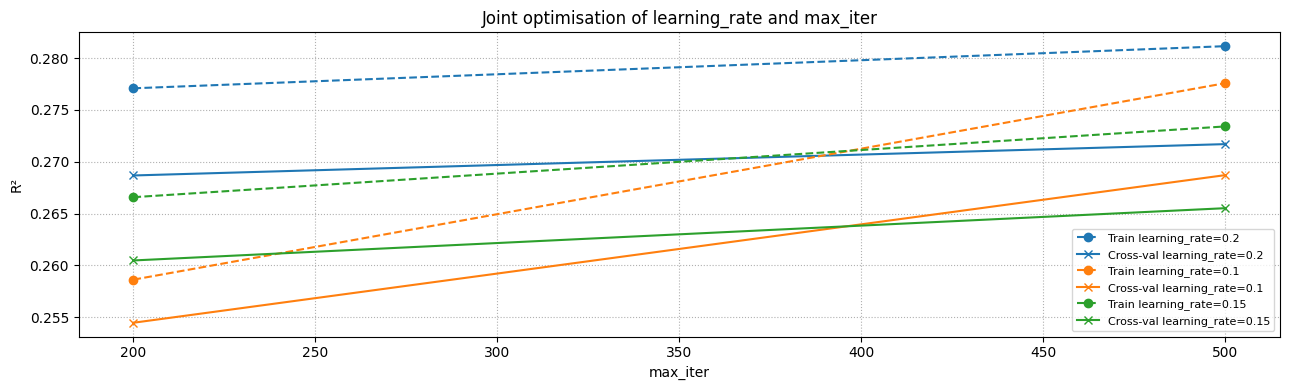

In [50]:
plot_results_cv("max_iter", df_step1)

In [51]:
BEST_ITER = 500  # to automatically catch the best hyperparameter, set to : gs_step1.best_params_["regressor__GB__max_iter"]
BEST_LR = 0.25  # to automatically catch the best hyperparameter, set to : gs_step1.best_params_["regressor__GB__learning_rate"]

In [52]:
param_grid_step2 = {
    "regressor__GB__max_depth" : [3, 5, 8],
    "regressor__GB__min_samples_leaf": [10, 20, 50],
}

gb_pipeline_step2 = Pipeline([
    ('preprocessing', preprocessor),
    ('GB', HistGradientBoostingRegressor(
        max_iter=BEST_ITER,
        learning_rate=BEST_LR,
        random_state=RANDOM_STATE,
        early_stopping=True
    ))
])

model_step2 = TransformedTargetRegressor(
    regressor=gb_pipeline_step2,
    transformer=y_transformer
)

gs_step2 = GridSearchCV(
    estimator=model_step2,
    param_grid=param_grid_step2,
    cv=2,
    scoring="r2",
    return_train_score=True,
    n_jobs=-1,
    verbose=1,
)

gs_step2.fit(X_train, y_train)

print(f"Best params : {gs_step2.best_params_}")
print(f"Best CV R² : {gs_step2.best_score_:.4f}")

Fitting 2 folds for each of 9 candidates, totalling 18 fits


/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/wor

Best params : {'regressor__GB__max_depth': 8, 'regressor__GB__min_samples_leaf': 50}
Best CV R² : 0.2723


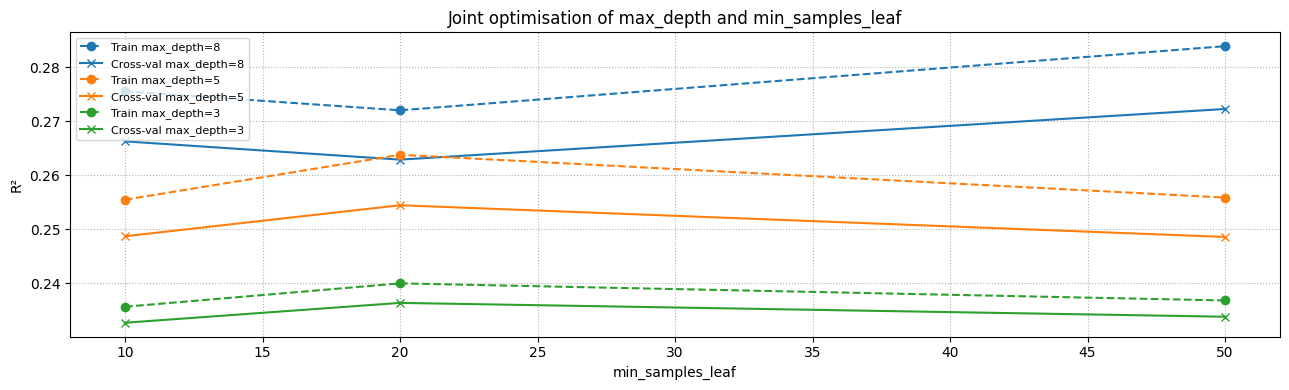

In [53]:
df_step2 = results_to_df(gs_step2.cv_results_)

plot_results_cv("min_samples_leaf", df_step2)

In [54]:
BEST_DEPTH = 20 # to automatically catch the best hyperparameter, set to : gs_step2.best_params_["regressor__GB__max_depth"]
BEST_MIN_LEAF = 75 # to automatically catch the best hyperparameter, set to : gs_step2.best_params_["regressor__GB__min_samples_leaf"]

Fitting 2 folds for each of 5 candidates, totalling 10 fits


/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/wor

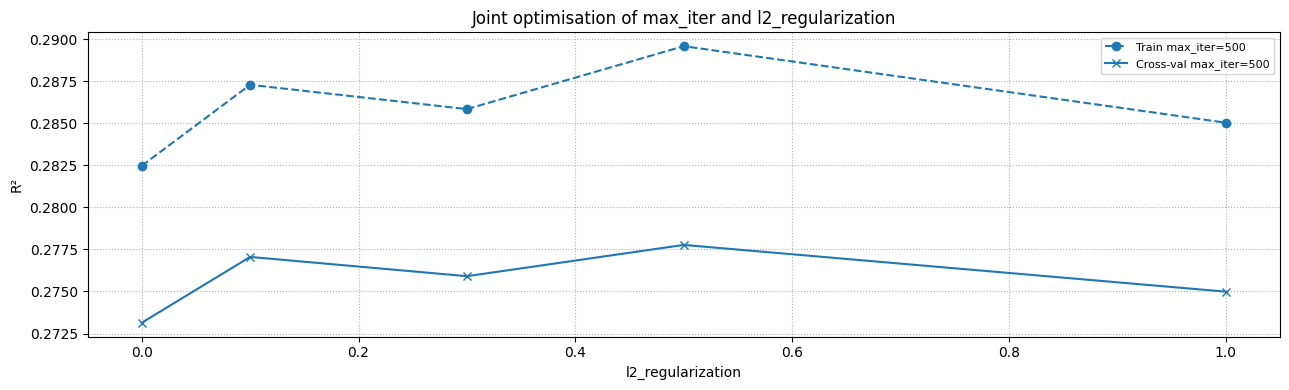

Best params : {'regressor__GB__l2_regularization': 0.5, 'regressor__GB__max_iter': 500}
Best CV R² : 0.2778


In [55]:
param_grid_step3 = {
    "regressor__GB__l2_regularization" : [0.0, 0.1, 0.3, 0.5, 1.0],
    "regressor__GB__max_iter" : [BEST_ITER],
}

gb_pipeline_step3 = Pipeline([
    ('preprocessing', preprocessor),
    ('GB', HistGradientBoostingRegressor(
        learning_rate=BEST_LR,
        max_depth=BEST_DEPTH,
        min_samples_leaf=BEST_MIN_LEAF,
        random_state=RANDOM_STATE,
        early_stopping=True
    ))
])

model_step3 = TransformedTargetRegressor(
    regressor=gb_pipeline_step3,
    transformer=y_transformer
)

gs_step3 = GridSearchCV(
    estimator=model_step3,
    param_grid=param_grid_step3,
    cv=2,
    scoring="r2",
    return_train_score=True,
    n_jobs=-1,
    verbose=1,
)

gs_step3.fit(X_train, y_train)

df_step3 = results_to_df(gs_step3.cv_results_)
plot_results_cv("l2_regularization", df_step3)

print(f"Best params : {gs_step3.best_params_}")
print(f"Best CV R² : {gs_step3.best_score_:.4f}")

In [56]:
BEST_L2 = 0 # to automatically catch the best hyperparameter, set to : gs_step3.best_params_["regressor__GB__l2_regularization"]

In [57]:
from sklearn.model_selection import train_test_split

gb_final = HistGradientBoostingRegressor(
    max_iter=BEST_ITER,
    learning_rate=BEST_LR,
    max_depth=BEST_DEPTH,
    min_samples_leaf=BEST_MIN_LEAF,
    l2_regularization=BEST_L2,
    random_state=RANDOM_STATE,
)

df = pd.read_parquet("https://minio.lab.sspcloud.fr/projet-funathon/2026/project1/data/2_preprocessing/df.parquet")

X = df.drop(columns=["price_sqm"])
y = df["price_sqm"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

# Wrap in the same pipeline / TransformedTargetRegressor as the RF section
gb_pipeline_best = Pipeline([
    ("preprocessor", preprocessor),  # same preprocessor as defined in the preprocessing section
    ("GB", gb_final),
])

gb_model_final = TransformedTargetRegressor(
    regressor=gb_pipeline_best,
    transformer=y_transformer  # same targettransformer as defined in preprocessing section
)

gb_model_final.fit(X_train, y_train)
print("Final model trained.")

/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/wor

Final model trained.


In [58]:
list = [("train", X_train, y_train), ("test", X_test, y_test)]

for split, X, y in list:
    print_metrics(gb_model_final, split, X, y)

/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


train — RMSE: 2735.02  |  MAE: 1712.49  |  R²: 0.3044


/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


test — RMSE: 2757.83  |  MAE: 1730.26  |  R²: 0.2967


In [59]:
y_pred_test = gb_model_final.predict(X_test)
predicted_actual_plot(y_test, y_pred_test, "Gradient Boosting")

/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


NameError: name 'predicted_actual_plot' is not defined

In [ ]:
import pandas as pd

# Build a DataFrame with one row per address — batching is faster than
# calling predict() in a loop and ensures consistent column ordering.
rows = []
for key, infos in prediction_examples.items():
    features = build_feature_dict(
        loc_x=infos["loc_x"],
        loc_y=infos["loc_y"],
        fare_a=infos["fare_a"],
        prop_type=infos["prop_type"],
    )
    features["adresse"] = infos["nom"]
    features["id"] = key
    rows.append(features)

X_examples = pd.DataFrame(rows)

# Keep metadata aside; the model only sees the feature columns it was trained on.
meta_cols = ["id", "adresse"]
feature_cols = [c for c in X_examples.columns if c not in meta_cols]

# Predicted price per square meter
predicted_price_sqm = gb_model_final.predict(X_examples[feature_cols])

results = X_examples[meta_cols].copy()
results["price_per_sqm"] = predicted_price_sqm.round(0)
results["surface"]       = X_examples["farea"].values
results["total_price"]   = (results["price_per_sqm"] * results["surface"]).round(0)

for _, row in results.iterrows():
    print(
        f"For the property at {row['adresse']} "
        f"({row['surface']:.0f} sqm), the estimated price is "
        f"{row['price_per_sqm']:,.0f} €/sqm, "
        f"i.e. a total of about {row['total_price']:,.0f} €."
    )

# Part 3

In [139]:
# best RF
y_pred_RF = rf_model_final.predict(X_test)
rf_residuals = y_test - y_pred_RF

# best GB
y_pred_GB = gb_model_final.predict(X_test)
gb_residuals = y_test - y_pred_GB

In [140]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

def print_metrics(model, split, X=X_train, y=y_train):
    """
    Print metrics for trained model
    """
    y_pred = model.predict(X)
    rmse = root_mean_squared_error(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    r2  = r2_score(y, y_pred)
    print(f"{split} — RMSE: {rmse:.2f}  |  MAE: {mae:.2f}  |  R²: {r2:.4f}")

models = [("RF", rf_model_final), ("GB", gb_model_final)]

for name, model in models:
    print_metrics(model, name, X_test, y_test)

RF — RMSE: 2936.34  |  MAE: 1848.52  |  R²: 0.2027
GB — RMSE: 2757.83  |  MAE: 1730.26  |  R²: 0.2967


In [141]:
# Disponible à partir de scikit-learn >= 0.24
from sklearn.metrics import mean_absolute_percentage_error

mape_pct_rf = mean_absolute_percentage_error(y_test, y_pred_RF) * 100
mape_pct_gb = mean_absolute_percentage_error(y_test, y_pred_GB) * 100
print(f"MAPE RF: {mape_pct_rf:.2f} %")
print(f"MAPE GB: {mape_pct_gb:.2f} %")

MAPE RF: 67.34 %
MAPE GB: 60.33 %


In [62]:
import matplotlib.pyplot as plt

def residuals_distribution(residuals: pd.Series, rmse: float, ax=None, label=None, color=None):
    if ax is None:
        fig, ax = plt.subplots()
    ax.hist(residuals, bins=100, edgecolor="none", alpha=0.5, label=label or f"RMSE = {rmse:.3f}", color=color)
    ax.axvline(0, color="red", linestyle="--")
    ax.set_xlabel("Residual")
    ax.set_ylabel("Frequency")
    ax.set_title("Residuals distribution")
    ax.legend()
    return ax

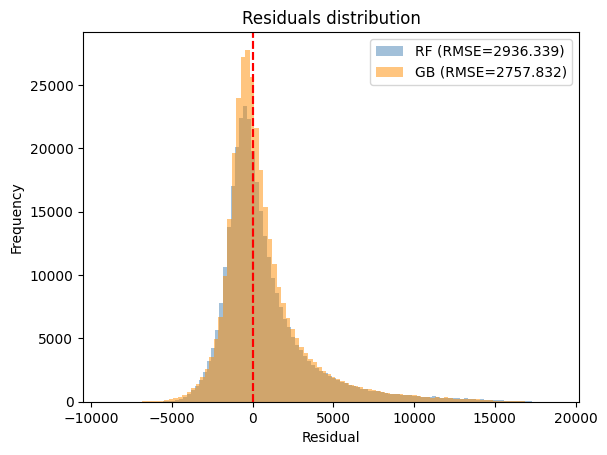

In [144]:
rmse_rf = root_mean_squared_error(y_test, y_pred_RF)
rmse_gb = root_mean_squared_error(y_test, y_pred_GB)

fig, ax = plt.subplots()
residuals_distribution(rf_residuals, rmse_rf, ax=ax, label=f"RF (RMSE={rmse_rf:.3f})", color="steelblue")
residuals_distribution(gb_residuals, rmse_gb, ax=ax, label=f"GB (RMSE={rmse_gb:.3f})", color="darkorange")
plt.show()

In [63]:
import numpy as np

def QQplot(y_test: pd.Series, y_pred: pd.Series, ax=None, label=None, color=None):
    """
    Actual quantiles vs predicted quantiles
    """
    quantiles = np.linspace(0, 100, 1000)
    q_real = np.percentile(y_test, quantiles)
    q_predict = np.percentile(y_pred, quantiles)

    if ax is None:
        fig, ax = plt.subplots()
    ax.scatter(q_real, q_predict, alpha=0.5, s=5, label=label or "Quantiles", color=color)
    ax.plot(
        [q_real[0], q_real[-1]],
        [q_real[0], q_real[-1]],
        "r--", linewidth=1.5
    )
    ax.set_xlabel("Actual quantiles")
    ax.set_ylabel("Predicted quantiles")
    ax.set_title("QQ-plot: actual vs predicted")
    ax.legend()
    return ax

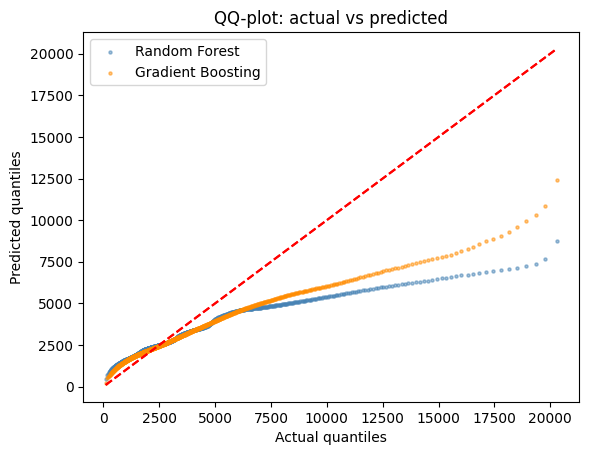

In [146]:
fig, ax = plt.subplots()
QQplot(y_test, y_pred_RF, ax=ax, label="Random Forest", color="steelblue")
QQplot(y_test, y_pred_GB, ax=ax, label="Gradient Boosting", color="darkorange")
plt.show()

In [64]:
def target_distribution(y: pd.Series):
    y_sorted = np.sort(y)
    axe = np.linspace(0, 100, len(y_sorted))   # axe with percentiles

    fig = plt.figure()
    plt.plot(axe, y_sorted)
    plt.xlabel("Percentile")
    plt.ylabel("Value (EUR)")
    plt.title("Distribution")
    return fig

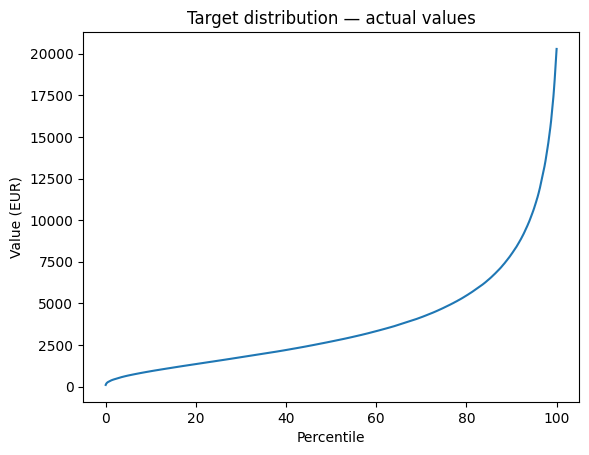

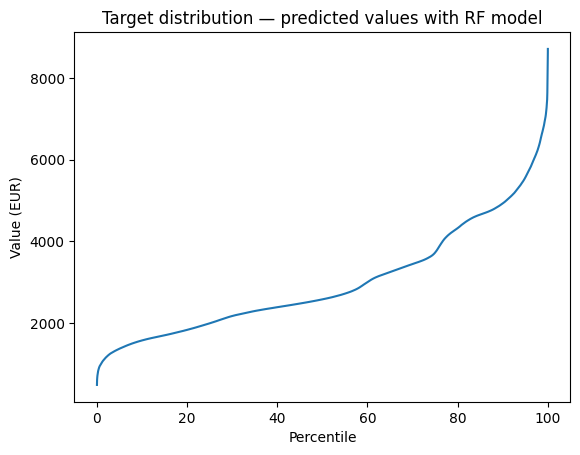

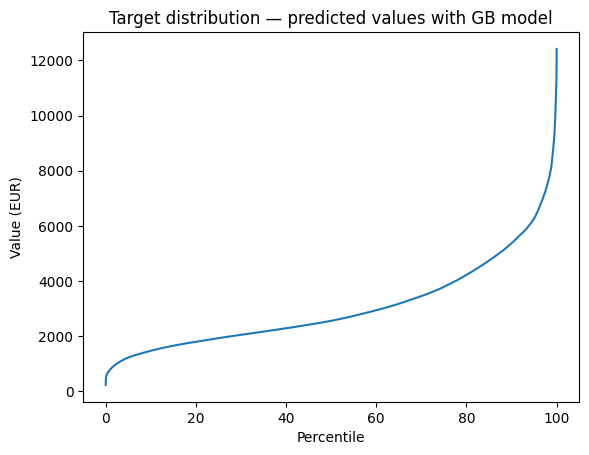

In [148]:
fig_actual = target_distribution(y_test)
plt.title("Target distribution — actual values")
plt.show()

fig_pred = target_distribution(y_pred_RF)
plt.title("Target distribution — predicted values with RF model")
plt.show()

fig_pred = target_distribution(y_pred_GB)
plt.title("Target distribution — predicted values with GB model")
plt.show()

In [66]:
from sklearn.inspection import permutation_importance

def calculate_importance(X_test, y_test, RANDOM_STATE, final_rf, SCORING):
    X_test_sample = X_test.sample(n=min(100_000, len(X_test)), random_state=RANDOM_STATE)
    y_test_sample = y_test.loc[X_test_sample.index]

    perm = permutation_importance(
        final_rf, X_test_sample, y_test_sample,
        n_repeats=5,
        scoring=SCORING,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )

    importances = (
        pd.Series(perm.importances_mean, index=X_test.columns)
        .sort_values(ascending=False)
    )
    return importances

In [65]:
def importance_plot(importances):
    """
    Permutation importance plot
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    importances.head(20).plot.barh(ax=ax)
    ax.invert_yaxis()
    ax.set_title("Permutation importance (top 20)")
    ax.set_xlabel("Mean increase in RMSE")
    plt.tight_layout()
    return fig

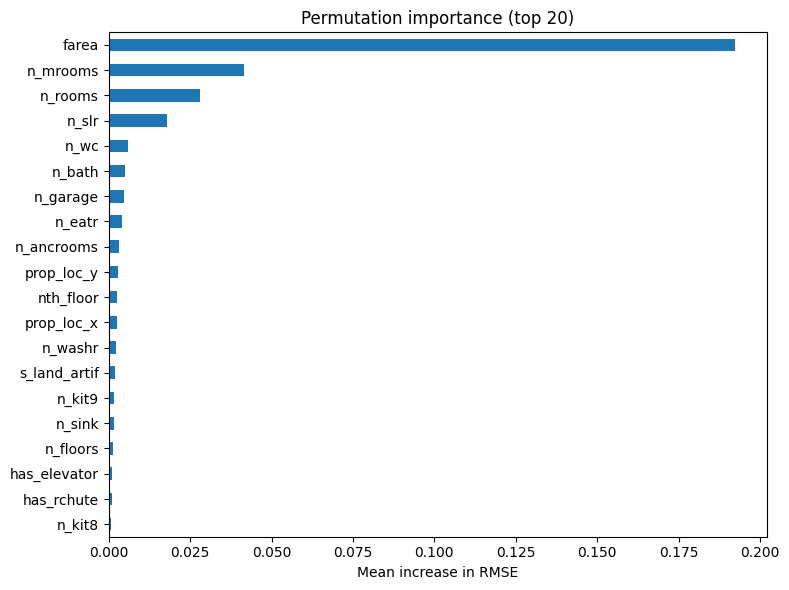

In [151]:
score = "r2"

importances = calculate_importance(X_test, y_test, RANDOM_STATE, rf_model_final, score)
fig_importance = importance_plot(importances)
plt.show()

# Part 5

In [60]:
import mlflow
import os

mlflow_server = os.getenv("MLFLOW_TRACKING_URI") # your environment feature for accessing to MLFlow server
mlflow.set_tracking_uri(mlflow_server)
mlflow.set_experiment("run_rf")

<Experiment: artifact_location='mlflow-artifacts:/2', creation_time=1779375308698, experiment_id='2', last_update_time=1779375308698, lifecycle_stage='active', name='run_rf', tags={}, trace_location=None, workspace='default'>

In [ ]:
from mlflow.models.signature import infer_signature

with mlflow.start_run(run_name="run_rf"):
    mlflow.set_tags({
        "model_type": "RandomForestRegressor",
        "task": "regression",
        "data_path": "https://minio.lab.sspcloud.fr/...",
        "target_col": y.name,
        "framework": "scikit-learn"
    })
    mlflow.log_params({
        "test_size": 0.2,
        "max_depth": 5,
        "min_samples_split": 2,
        "random_state": RANDOM_STATE,
        "n_train": len(X_train),
        "n_test": len(X_test),
        "n_features": X.shape[1],
        "target_mean": round(float(y.mean()), 4),
        "target_std": round(float(y.std()), 4),
        "oob_score": True,
        "n_jobs": -1
    })

    mlflow.log_params(grid_search.best_params_)

    y_pred = rf_model_final.predict(X_test)
    residuals = y_test - y_pred

    metrics = {
        "neg_root_mean_squared_error": root_mean_squared_error(y_test, y_pred),
        "neg_mean_absolute_error": mean_absolute_error(y_test, y_pred),
        "r2": r2_score(y_test, y_pred),
    }

    mlflow.log_metrics(metrics)

    signature = infer_signature(X_train, rf_model_final.predict(X_train))

    mlflow.sklearn.log_model(
        sk_model=rf_model_final,
        name="RF",
        signature=signature,
        input_example=X_train.head(5),
        registered_model_name="rf-run",
    )

    print(f"Run ID : {mlflow.active_run().info.run_id}")

/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/work/funathon-project1/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/onyxia/wor